# Let Unitree Go2 Robot Dog Trotting and Walking
Import mujoco for simulation, jax for differentiable programming, brax for environment definition and mediapy for visualization.
Feel free to use other familiar libraries for illustration.

The notebook follows the assignment structure:
1. **Part 1** - RL environment for Unitree Go2 (observation/action spaces)
2. **Part 2** - Reward design for forward movement (3 terms)
3. **Part 3** - Trajectory optimization via gradient descent

In [57]:
import subprocess

# subprocess.run(['/usr/local/bin/python3', '-m', 'pip', 'install', 'brax'], check=True)
# subprocess.run(['/usr/local/bin/python3', '-m', 'pip', 'install', 'mediapy'], check=True)

In [58]:
import mujoco
import jax
import jax.numpy as jnp

from jax import config
config.update("jax_debug_nans", True)
config.update("jax_enable_x64", True)
config.update('jax_default_matmul_precision', 'high')

from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from IPython.display import HTML

import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

## Part 1 - RL Environment for Unitree Go2

The environment wraps the Unitree Go2 MuJoCo model in a brax `PipelineEnv` with the MJX backend.

The observation space has 24 dimensions, assembled from three pieces of the simulator state. Policy gets access to joint configuration, base velocity, and base attitude.

    12 come from `data.qpos[7:]` — the joint positions of the four legs, skipping the seven DoFs of the trunk's free joint (3 position + 4 quaternion). 

    3 come from the `global_linvel` IMU sensor - the trunk's linear velocity in the world frame. 

    9 entries come from `data.xmat[base]` - the trunk's rotation matrix flattened from its (3, 3) form
    
The action space is 12-dimensional, one entry per actuated leg joint: 3 joints per leg (hip, thigh, calf) across four legs (FL, FR, RL, RR), and each action is interpreted as a target joint position. The PD law on each actuator then converts that target into a torque.

Define an RL environment for quadrupedal locomotion for Unitree Go2 robot dog. The mujoco xml file can also be found from mujoco_menagerie library which hosts a zoo of robot models. Override the actuator gain to make the commanded motion better tracked. 

In [59]:
class QuadrupedUnitreeGo2(PipelineEnv):
    def __init__(self, **kwargs):
        self.mj_model = mujoco.MjModel.from_xml_path('unitree_go2/scene_mjx.xml')
        kp = 230
        self.mj_model.actuator_gainprm[:, 0] = kp
        self.mj_model.actuator_biasprm[:, 1] = -kp
        sys = mjcf.load_model(self.mj_model)
        physics_steps_per_control_step = 5
        kwargs['n_frames'] = kwargs.get('n_frames', physics_steps_per_control_step)
        kwargs['backend'] = 'mjx'

        super().__init__(sys, **kwargs)

        # added cache sensor / body lookups + nominal standing height
        sid = self.mj_model.sensor('global_linvel').id
        self._linvel_adr = self.mj_model.sensor_adr[sid]
        self._linvel_dim = self.mj_model.sensor_dim[sid]
        self._base_id = self.mj_model.body('base').id
        self._z_target = float(self.mj_model.keyframe('home').qpos[2])

    def reset(self, rng):
        init_qpos = self.mj_model.keyframe('home').qpos
        qpos = jnp.array(init_qpos)
        qvel = jnp.zeros((self.sys.nv,))

        data = self.pipeline_init(qpos, qvel)
        obs = self._get_obs(data)
        metrics = {
            'joint_pos_reward':   0.0,
            'base_height_reward': 0.0,
            'base_orient_reward': 0.0,
            'base_linvel_reward': 0.0,
        }
        return State(data, obs, 0, False, metrics)

    def _get_obs(self, data):
        #extract interested observations from state data
        position = data.qpos
        position = position[7:] #exclude the first free base link, keep only 1-dof joint position can be measured by encoders
        
        #IMU readings for base link
        sensor_id = self.mj_model.sensor('global_linvel').id
        sensor_adr = self.mj_model.sensor_adr[sensor_id]
        sensor_dim = self.mj_model.sensor_dim[sensor_id]
        base_linvel = data.sensordata[sensor_adr:sensor_adr+sensor_dim]    #count the index for global_linvel sensor
        
        base_rot = data.xmat[self.mj_model.body('base').id]

        return jnp.concatenate([
            position,
            base_linvel,
            base_rot.ravel(),
        ])

    def step(self, state, action):
        data = state.pipeline_state
        new_data = self.pipeline_step(data, action)
        obs = self._get_obs(new_data)

        # pull relevant info for reward calculation
        base_linvel = new_data.sensordata[self._linvel_adr:self._linvel_adr + self._linvel_dim]
        v_x = base_linvel[0]                        # forward velocity (world x)
        z = new_data.qpos[2]                        # trunk height (free joint z)
        base_rot = new_data.xmat[self._base_id]     # shape (3, 3) rotation matrix of the base link
        R02 = base_rot[0,2]                         # world-frame x/z of body z-axis
        R12 = base_rot[1,2]                         # world-frame y/z of body z-axis
        
        # weights
        w_vel = 10.0
        w_height = 50.0
        w_orient = 1.0

        # reward terms
        r_vel = w_vel * v_x
        r_height = -w_height * (z - self._z_target) ** 2
        r_orient = -w_orient * (R02 ** 2 + R12 ** 2)

        reward = r_vel + r_height + r_orient

        state.metrics.update({
            'base_linvel_reward': r_vel,
            'base_height_reward': r_height,
            'base_orient_reward': r_orient,
            'joint_pos_reward': 0.0,
        })

        return state.replace(pipeline_state=new_data, obs=obs, reward=reward, done=False)

## Part 2 - Reward design for moving forward

Three terms drive the trunk forward, keep it at standing height, and keep it upright.

### (a) Forward velocity - linear in $v_x$

$$r_{\text{vel}} = w_v \, v_x, \qquad w_v = 10.0$$

$v_x$ is the world-frame x-component of the trunk's linear velocity, read from the `global_linvel` IMU sensor. A *linear* reward (rather than a quadratic penalty around a target speed) gives a constant positive gradient pushing $v_x$ upward; this matters because the dog starts at rest, where a quadratic-around-$v^*$ would have weak gradient near $v_x = 0$. Need a weight larger than 1.0, or else it learns that standing still can be rewarded.

### (b) Trunk height - quadratic around the nominal standing height

$$r_{\text{height}} = -w_h \, (z - z^*)^2, \qquad w_h = 50.0$$

$z^*$ is set to `qpos[2]` of the `home` keyframe (the nominal standing height of the Go2, around 0.27-0.3 m). The quadratic penalises *both* dropping *and* lifting/hopping. Height varies on the cm scale, so a large weight is needed to make the term meaningful: a 2 cm error contributes ~0.02; a 15 cm drop contributes ~1.1.

### (c) Uprightness - penalty on horizontal projection of body z-axis

$$r_{\text{orient}} = -w_o \, (R_{02}^2 + R_{12}^2), \qquad w_o = 1.0$$

The third column of the trunk rotation matrix is the world-frame coordinates of the trunk's own z-axis. When the dog is upright that column is $[0,0,1]^\top$ and the penalty is zero. As the trunk tilts, $R_{02}$ and $R_{12}$ grow. This form has non-zero gradient as soon as the trunk leans, unlike $-(1 - R_{22})$ which is flat to first order near upright (because $R_{22} = \cos\theta_{\text{tilt}}$).

### Final reward

$$r_t = 10v_x \;-\; 50\,(z - z^*)^2 \;-\; (R_{02}^2 + R_{12}^2)$$

**Scale check.** Healthy trotting ($v_x = 0.5$, 2 cm height jitter, upright): $r_t \approx +0.48$ per step. Near-collapse ($v_x = 0.1$, 12 cm height drop, ~60deg tilt): $r_t \approx -1.2$ per step. Over a 50-step rollout that is the difference between ~+25 and ~-60 - well separated.

## Part 3 - Trajectory optimization

We prepare initialization of trajectory with the cyclic motion insight. This is from a [tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/mjx/training_apg.ipynb) and originated from [Marc Raibert](https://en.wikipedia.org/wiki/Marc_Raibert)'s heuristic. 

Then we refine it with gradient descent through the differentiable simulator. The total rollout reward is computed with `jax.lax.scan` over the physics steps, and `jax.grad` gives $\nabla_{\mathbf{u}_{0:T-1}}\, -\!\sum_t r_t$ via reverse-mode autodiff.

### Trotting reference (initial guess)

In [60]:
duration = 4
framerate = 50

env = QuadrupedUnitreeGo2()
jit_step = jax.jit(env.step)

def cos_wave(t, step_period, scale):
    _cos_wave = -jnp.cos(((2 * jnp.pi) / step_period) * t)
    return _cos_wave * (scale / 2) + (scale / 2)

def make_kinematic_ref(sinusoid, step_k, scale=0.3, dt=1 / 50):
    # Trotting kinematics for the 12 leg joints.
    # One gait cycle = 2 * step_k * dt seconds.
    _steps = jnp.arange(step_k)
    step_period = step_k * dt
    t = _steps * dt

    wave = sinusoid(t, step_period, scale)
    fleg_cmd_block = jnp.concatenate(
        [jnp.zeros((step_k, 1)),
         wave.reshape(step_k, 1),
         -2 * wave.reshape(step_k, 1)],
        axis=1
    )
    h_leg_cmd_bloc = 1 * fleg_cmd_block

    block1 = jnp.concatenate([
        jnp.zeros((step_k, 3)),
        fleg_cmd_block,
        h_leg_cmd_bloc,
        jnp.zeros((step_k, 3))],
        axis=1
    )
    block2 = jnp.concatenate([
        fleg_cmd_block,
        jnp.zeros((step_k, 3)),
        jnp.zeros((step_k, 3)),
        h_leg_cmd_bloc],
        axis=1
    )
    return jnp.concatenate([block1, block2], axis=0)

Check the cyclic reference motion by directly apply it to the robot. It generates some trotting but slightly backward motion since the reference motion is treated as joint trajectories in free space without considering ground contacts.

In [ ]:
kin_ref_qpos = make_kinematic_ref(cos_wave, 25, 0.3, 1./50) + jnp.array(env.mj_model.keyframe('home').qpos[7:])
kin_ref_qpos = jnp.concatenate([ kin_ref_qpos for _ in range(12)], axis=0)

state = env.reset(jax.random.PRNGKey(0))
rollout = [state.pipeline_state]
t = 0
while t < kin_ref_qpos.shape[0]:
  ctrl = jnp.array(kin_ref_qpos[t, :])
  state = jit_step(state, ctrl)
  # print(state.pipeline_state.qpos)
  rollout.append(state.pipeline_state)
  t+=1

# TODO: READ, for both initial rollout + the optimized rollout, you 
# can comment out the html and just run media.show_video
# I just had to use html to visualize the rollout
# since media.show_video doesn't work for me

html_str = html.render(env.sys, [s for s in rollout])

with open('rollout1.html', 'w') as f:
    f.write(html_str)
print("Saved to rollout1.html")

# display(HTML(html_str))
# media.show_video(env.render(rollout), fps=1.0/env.dt)

Saved to rollout1.html


### Build the loss and gradient

`rollout_loss` integrates the env forward under a control sequence and accumulates $-\sum_t r_t$. We `jit` both the loss and its gradient.

In [62]:
def _simulate_rollout(init_state, ctrl_array):
    def _scan_step(carry, u):
        new_state = jit_step(carry, u)
        return new_state, new_state
    _, state_traj = jax.lax.scan(_scan_step, init_state, ctrl_array)
    return state_traj

def rollout_loss(ctrl_array):
    init_state = env.reset(jax.random.PRNGKey(0))
    state_rollout = _simulate_rollout(init_state, ctrl_array)

    def _scan_cost(carry, s):
        return carry + (-s.reward), -s.reward

    tol_loss, _ = jax.lax.scan(_scan_cost, 0.0, state_rollout)
    return tol_loss

jit_loss_fun  = jax.jit(lambda ctrl: rollout_loss(ctrl.reshape((-1, 12))))
jit_loss_grad = jax.jit(jax.grad(jit_loss_fun))

In [63]:
# Checking if the loss and gradient functions are reasonable
# print(jit_loss_fun(kin_ref_qpos.ravel()))
# print(jit_loss_grad(kin_ref_qpos.ravel()))

### Gradient descent loop

Plain gradient descent with gradient-norm clipping. Clipping matters here because we are back-propagating through hundreds of physics steps; contact transients can spike the gradient norm if a foot makes an unlucky impact.

- **Learning rate** `1e-3` (drop to `1e-4` if the loss diverges; raise to `5e-3` if it barely moves).
- **300 iterations** should be enough to see the dog move forward
- **Decision-variable size**: $T \times 12$ joint targets. With the 300-step trot reference that is ~3,600 scalars.

In [64]:
ctrl = kin_ref_qpos.ravel()

learning_rate = 1e-3
n_iters       = 500
clip_norm     = 5.0

loss_history = []
for i in range(n_iters):
    loss  = jit_loss_fun(ctrl)
    grad  = jit_loss_grad(ctrl)
    gnorm = jnp.linalg.norm(grad)
    grad  = jnp.where(gnorm > clip_norm, grad * (clip_norm / gnorm), grad)
    ctrl  = ctrl - learning_rate * grad
    loss_history.append(float(loss))
    if i % 10 == 0:
        print(f"iter {i:4d}: loss = {float(loss):+9.4f}   |grad| = {float(gnorm):8.4f}")

iter    0: loss = +196.3069   |grad| = 1942.6519
iter   10: loss = +163.8140   |grad| = 2526.2389
iter   20: loss = +119.9798   |grad| = 2110.0769
iter   30: loss =  +87.5223   |grad| = 1777.9657
iter   40: loss =  +54.0084   |grad| = 2258.2612
iter   50: loss =  +43.6997   |grad| = 2444.0311
iter   60: loss =  +21.0828   |grad| = 2363.0784
iter   70: loss =   -2.7432   |grad| = 2466.9468
iter   80: loss =  -30.0904   |grad| = 2312.4983
iter   90: loss =  -52.1212   |grad| = 2443.7399
iter  100: loss =  -72.7541   |grad| = 2383.8114
iter  110: loss =  -91.5870   |grad| = 2423.1432
iter  120: loss = -127.1613   |grad| = 2047.1870
iter  130: loss = -151.6549   |grad| = 1900.2159
iter  140: loss = -169.6640   |grad| = 2358.9159
iter  150: loss = -184.5042   |grad| = 2128.4489
iter  160: loss = -221.0153   |grad| = 2978.2269
iter  170: loss = -254.8474   |grad| = 1711.3702
iter  180: loss = -268.6638   |grad| = 1763.5886
iter  190: loss = -307.7007   |grad| = 1871.1033
iter  200: loss = -3

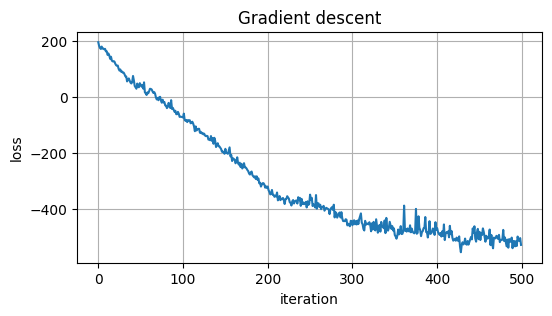

In [68]:
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.xlabel('iteration'); plt.ylabel('loss')
plt.title('Gradient descent')
plt.grid(True); plt.show()

### Roll out the optimized control and check forward progress

In [66]:
state    = env.reset(jax.random.PRNGKey(0))
rollout  = [state.pipeline_state]
ctrl_seq = ctrl.reshape((-1, 12))

x_pos = [float(state.pipeline_state.qpos[0])]
z_pos = [float(state.pipeline_state.qpos[2])]
for t in range(ctrl_seq.shape[0]):
    state = jit_step(state, ctrl_seq[t])
    rollout.append(state.pipeline_state)
    x_pos.append(float(state.pipeline_state.qpos[0]))
    z_pos.append(float(state.pipeline_state.qpos[2]))

print(f"Trunk x: {x_pos[0]:+.3f} m  ->  {x_pos[-1]:+.3f} m")
print(f"Trunk z (height) min/mean/max: {min(z_pos):.3f} / {np.mean(z_pos):.3f} / {max(z_pos):.3f} m")

# media.show_video(env.render(rollout), fps=1.0 / env.dt)
html_str = html.render(env.sys, [s for s in rollout])

with open('rollout2.html', 'w') as f:
    f.write(html_str)
print("Saved to rollout2.html")

# display(HTML(html_str))

Trunk x: +0.000 m  ->  +0.518 m
Trunk z (height) min/mean/max: 0.252 / 0.269 / 0.295 m
Saved to rollout2.html


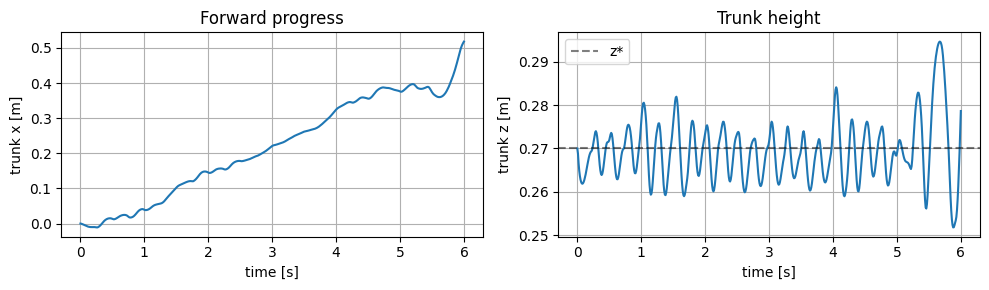

In [67]:
t_axis = np.arange(len(x_pos)) * env.dt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t_axis, x_pos);  axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('trunk x [m]'); axes[0].set_title('Forward progress'); axes[0].grid(True)
axes[1].plot(t_axis, z_pos);  axes[1].axhline(env._z_target, color='k', ls='--', alpha=0.5, label='z*')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('trunk z [m]'); axes[1].set_title('Trunk height'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()